Dataset:
      Date  Sales  Profit Region Product
0  2024-01  34462   12739   East  Mobile
1  2024-02  51650   13585  North  Tablet
2  2024-03  40073    5941   East  Tablet
3  2024-04  66787   12611   East  Tablet
4  2024-05  55661    6281   West  Mobile

Forecasted Sales:
        Date  Forecasted_Sales
0 2026-01-31          62843.00
1 2026-02-28          63478.06
2 2026-03-31          64113.12
3 2026-04-30          64748.18
4 2026-05-31          65383.24
5 2026-06-30          66018.30


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/tmp/ipykernel_5788/3463864642.py:39: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(


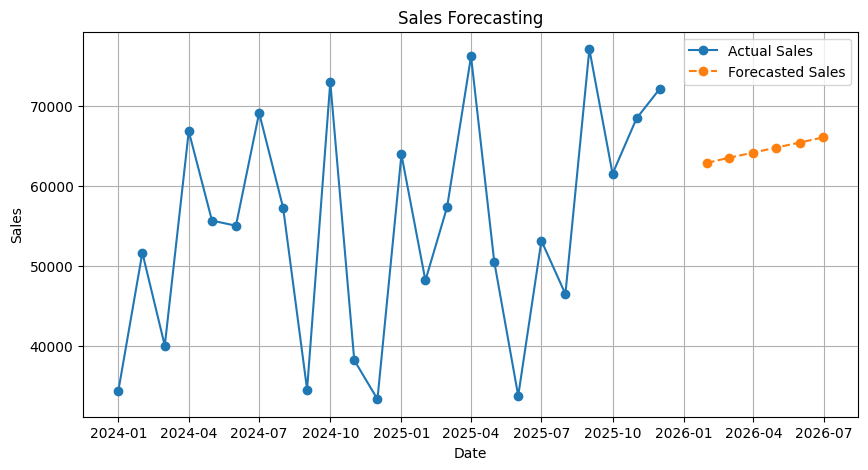

In [1]:
# ==========================
# SALES FORECASTING PROJECT
# ==========================

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np

# Load CSV File
df = pd.read_csv("sales_forecasting_dataset.csv")

# Show Dataset
print("Dataset:")
print(df.head())

# Convert Date column
df['Date'] = pd.to_datetime(df['Date'])

# Sort by Date
df = df.sort_values('Date')

# Create Month Number
df['Month_Number'] = range(1, len(df)+1)

# X and Y data
X = df[['Month_Number']]
y = df['Sales']

# Train Model
model = LinearRegression()
model.fit(X, y)

# Predict Future 6 Months
future_months = np.array(range(len(df)+1, len(df)+7)).reshape(-1,1)
forecast = model.predict(future_months)

# Create Future Dates
future_dates = pd.date_range(
    start=df['Date'].max(),
    periods=7,
    freq='M'
)[1:]

# Forecast DataFrame
forecast_df = pd.DataFrame({
    'Date': future_dates,
    'Forecasted_Sales': forecast
})

print("\nForecasted Sales:")
print(forecast_df)

# Plot Actual Sales
plt.figure(figsize=(10,5))
plt.plot(df['Date'], df['Sales'],
         marker='o',
         label='Actual Sales')

# Plot Forecast Sales
plt.plot(forecast_df['Date'],
         forecast_df['Forecasted_Sales'],
         marker='o',
         linestyle='dashed',
         label='Forecasted Sales')

plt.title("Sales Forecasting")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()